# TUS simulation safety parameter plots

In [15]:
import utils
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn-v0_8')

pd.set_option('display.max_columns', None)

In [16]:
# Make output folder
plot_dir = f'/Volumes/kenvdzee/Documents/phd_1_analysis/plots/TUS/acoustic_simulations/post-hoc'
if not os.path.exists(plot_dir):
    os.makedirs(plot_dir)

## Find mean ipa file in simulations folder

In [17]:
simulation_results_dataframe = '/Volumes/project/3025011.02/TUS_simulations/simulation_results.csv'

simulation_results_dataframe = pd.read_csv(simulation_results_dataframe)

print(simulation_results_dataframe)

     subject condition      target                 region  mean_Ipa      Isppa
0    sub-039  planning  target_1_1          amygdala_left  1.547043   6.539772
1    sub-048  planning  target_1_1          amygdala_left  1.361474   4.848793
2    sub-049  planning  target_1_1          amygdala_left  1.794262   6.696591
3    sub-052  planning  target_1_1          amygdala_left  1.264882   3.715534
4    sub-053  planning  target_1_1          amygdala_left  1.462923   6.227767
..       ...       ...         ...                    ...       ...        ...
343  sub-065  post-hoc  target_2_4  payam_dacc_right_mask  2.352015   6.015797
344  sub-066  post-hoc  target_2_4  payam_dacc_right_mask  4.215404   9.732780
345  sub-067  post-hoc  target_2_4  payam_dacc_right_mask  4.381188  11.819160
346  sub-068  post-hoc  target_2_4  payam_dacc_right_mask  2.544498   7.092545
347  sub-061  post-hoc  target_2_5   payam_dacc_left_mask  1.050831   6.521862

[348 rows x 6 columns]


# Mean Ipa in relevant target

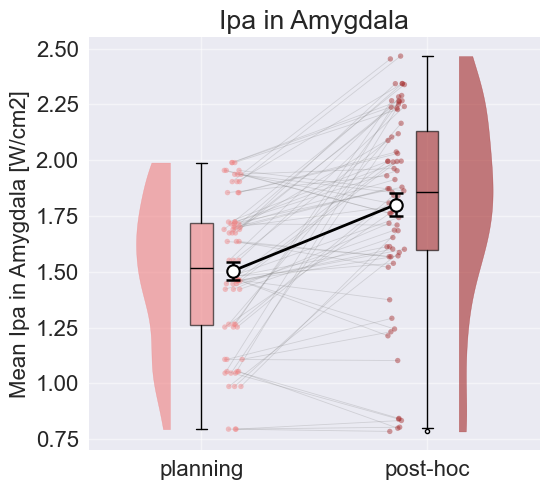

In [18]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_1')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='mean_Ipa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    colours=['lightcoral','brown'],
    output_dir=plot_dir,
    ylabel_name='Mean Ipa in Amygdala [W/cm2]',
    plot_name='Ipa in Amygdala',
    font_scale=1.6
);

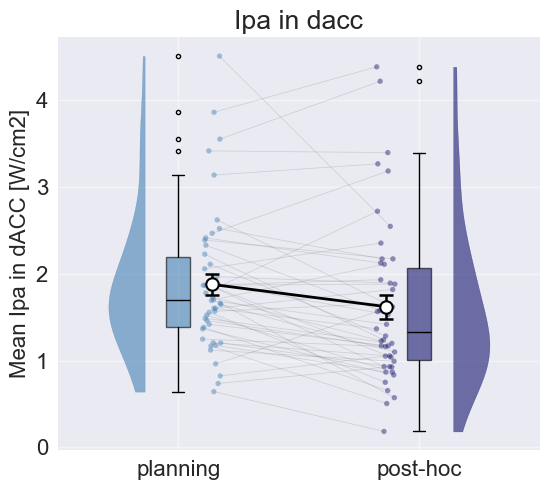

In [19]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_2')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='mean_Ipa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    colours=['steelblue','midnightblue'],
    output_dir=plot_dir,
    ylabel_name='Mean Ipa in dACC [W/cm2]',
    plot_name='Ipa in dacc',
    font_scale=1.6
);

# Isppa in relevant target

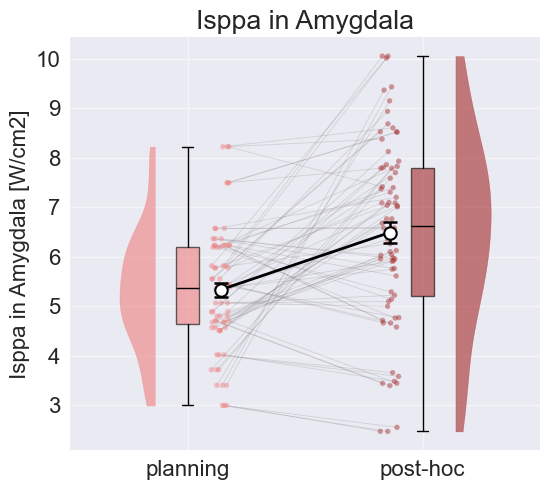

In [20]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_1')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='Isppa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    colours=['lightcoral','brown'],
    output_dir=plot_dir,
    ylabel_name='Isppa in Amygdala [W/cm2]',
    plot_name='Isppa in Amygdala',
    font_scale=1.6
);

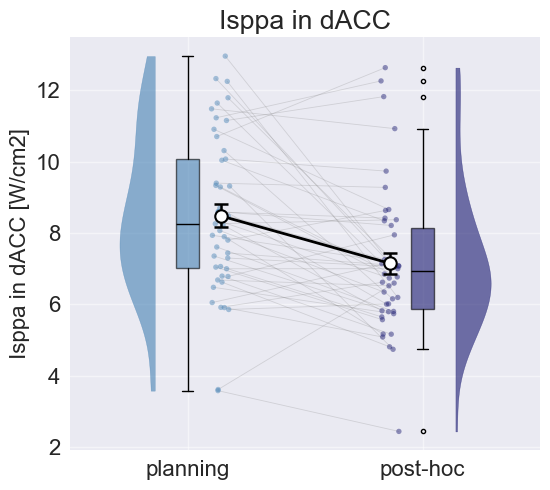

In [21]:
simulation_results_dataframe_filtered = simulation_results_dataframe.loc[simulation_results_dataframe['target'].str.contains('target_2')]

# Single-pass aggregation & reshape
simulation_results_pivoted = (
    simulation_results_dataframe_filtered
    .pivot_table(
        index=['subject', 'target'],
        columns='condition',
        values='Isppa',
        aggfunc='mean'
    )
    .reset_index()
)
simulation_results_pivoted = simulation_results_pivoted.rename_axis(None, axis=1)

# Plot the two groups using a raincloud plot
utils.plotting_functions.paired_raincloud(
    simulation_results_pivoted,
    columns=['planning','post-hoc'],
    flip=['left','right'],
    colours=['steelblue','midnightblue'],
    output_dir=plot_dir,
    ylabel_name='Isppa in dACC [W/cm2]',
    plot_name='Isppa in dACC',
    font_scale=1.6
);